<a href="https://colab.research.google.com/github/hariharan-vs/24ADI003---24BAD030/blob/main/ML_LAB_EX_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hariharan V S - 24BAD030
Support = 0.01, Itemsets = 3016
Support = 0.02, Itemsets = 894
Support = 0.05, Itemsets = 165
Confidence = 0.2, Rules = 1409
Confidence = 0.4, Rules = 555
Confidence = 0.6, Rules = 37
Frequent Itemsets:
     support         itemsets
0  0.078502       (UHT-milk)
1  0.031042  (baking powder)
2  0.119548           (beef)
3  0.079785        (berries)
4  0.062083      (beverages)

Association Rules:
                            antecedents         consequents   support  \
0                           (UHT-milk)  (other vegetables)  0.038994   
3                           (UHT-milk)        (whole milk)  0.040534   
4                               (beef)  (other vegetables)  0.050795   
7                               (beef)        (whole milk)  0.064135   
9                            (berries)  (other vegetables)  0.036942   
..                                 ...                 ...       ...   
860      (sausage, rolls/buns, yogurt)        (whole milk)  0.022832   


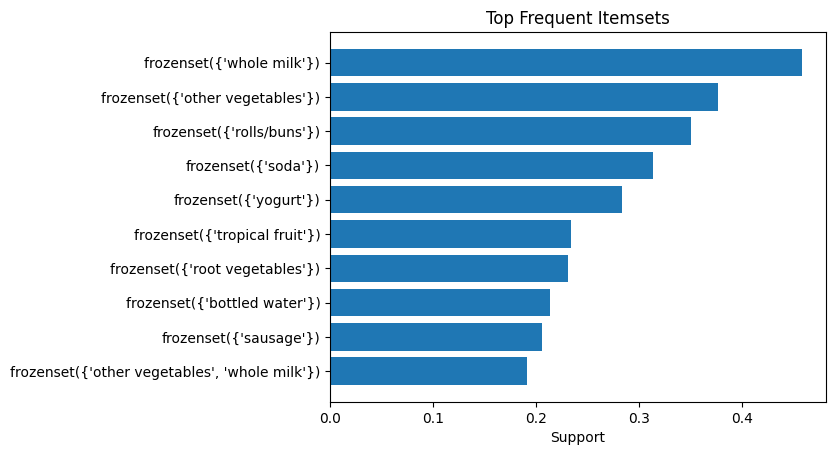

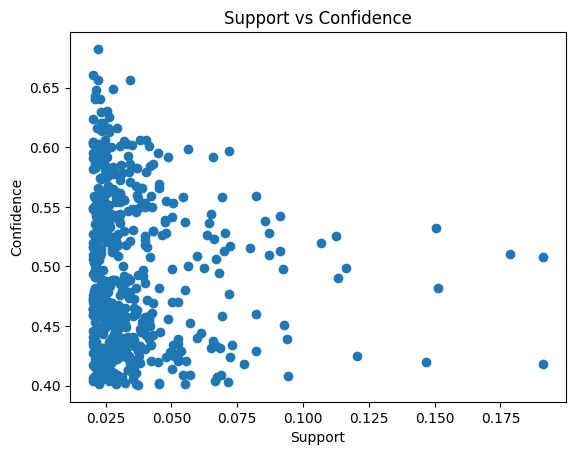

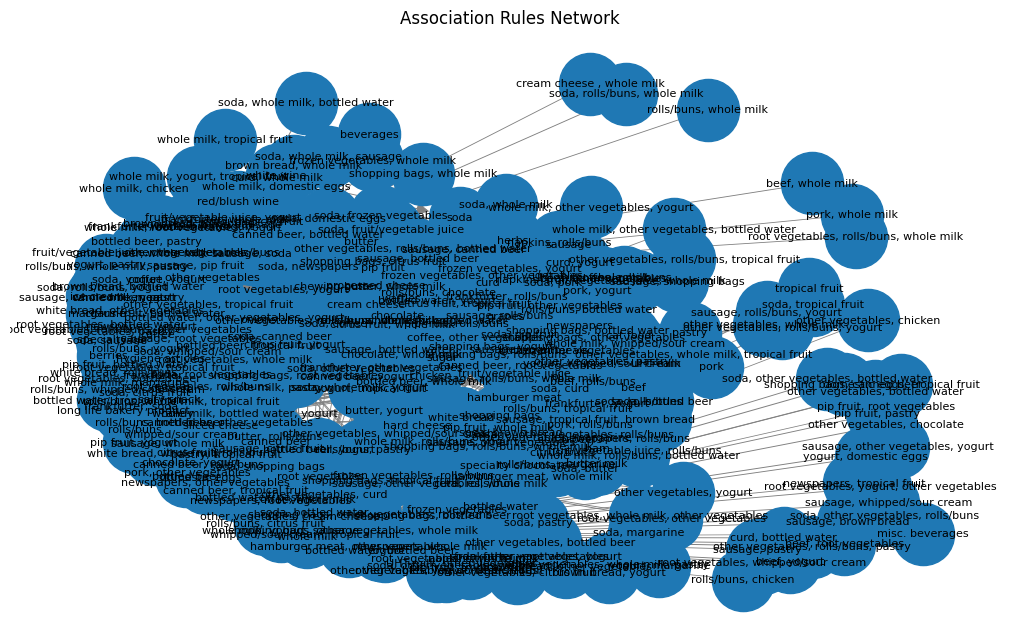

In [6]:
print("Hariharan V S - 24BAD030")
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import networkx as nx

df = pd.read_csv('/content/exp 8 ml Groceries_dataset.csv')

transactions = df.groupby('Member_number')['itemDescription'].apply(list)
transactions_list = transactions.tolist()

te = TransactionEncoder()
te_array = te.fit(transactions_list).transform(transactions_list)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

rules = rules[(rules['confidence'] > 0.4) & (rules['lift'] > 1)]

for support in [0.01, 0.02, 0.05]:
    temp = apriori(df_encoded, min_support=support, use_colnames=True)
    print(f"Support = {support}, Itemsets = {len(temp)}")

for conf in [0.2, 0.4, 0.6]:
    temp_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
    print(f"Confidence = {conf}, Rules = {len(temp_rules)}")

print("Frequent Itemsets:\n", frequent_itemsets.head())
print("\nAssociation Rules:\n", rules[['antecedents','consequents','support','confidence','lift']])

top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure()
plt.barh(top_items['itemsets'].astype(str), top_items['support'])
plt.xlabel("Support")
plt.title("Top Frequent Itemsets")
plt.gca().invert_yaxis()
plt.show()

plt.figure()
plt.scatter(rules['support'], rules['confidence'])
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")
plt.show()

# Prepare data for network graph
G = nx.DiGraph()
for _, rule in rules.iterrows():
    antecedent = ', '.join(list(rule['antecedents']))
    consequent = ', '.join(list(rule['consequents']))
    G.add_edge(antecedent, consequent, weight=rule['lift'])

plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=8, arrowsize=20, edge_color='gray', width=[G[u][v]['weight']/2 for u,v in G.edges()])
plt.title("Association Rules Network")
plt.show()

Hariharan V S - 24BAD030
Missing values:
 class                           0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

Explained Variance Ratio:
 [0.3996507  0.16770494 0.10920338 0.0683296  0.06528109 0.05148865
 0.04248671 0.02680753 0.02028839 0.01995798 0.01304329 0.01042324
 0.00533449]

Cumulative Variance:
 [0.3996507  0.56735564 0.67655902 0.74488863 0.81016972 0.86165837
 0.90414508 0.93095261 0.951241   0.97119898 0.98424227 0.99466551
 1.        ]


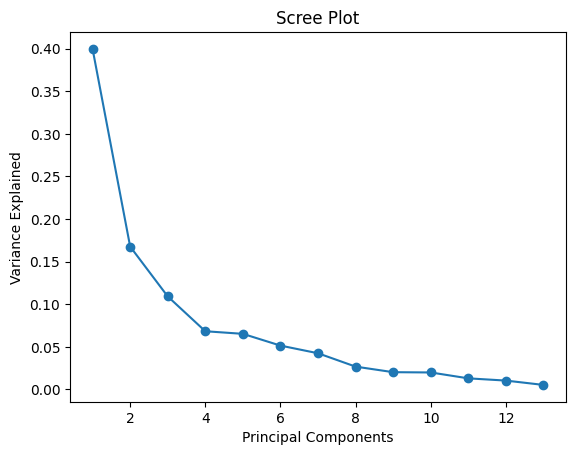

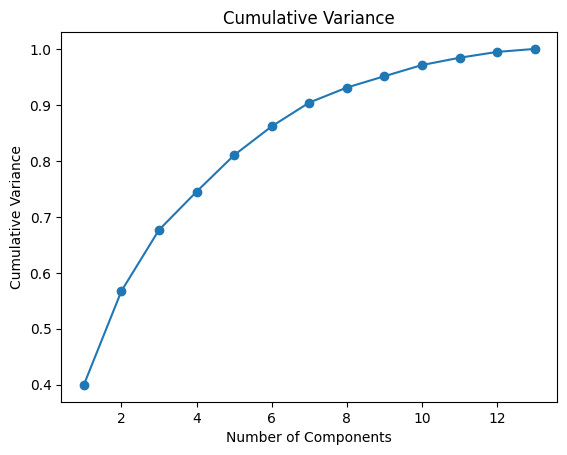

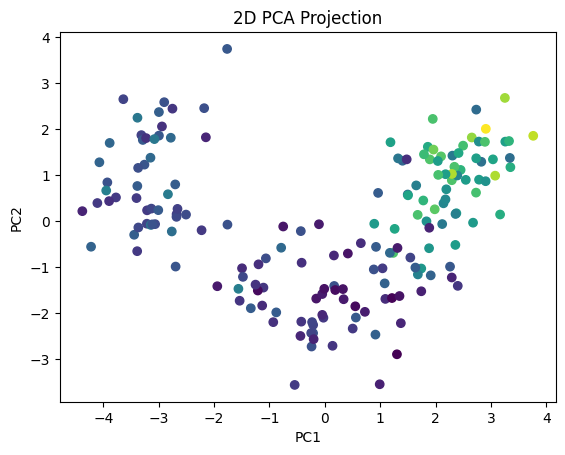

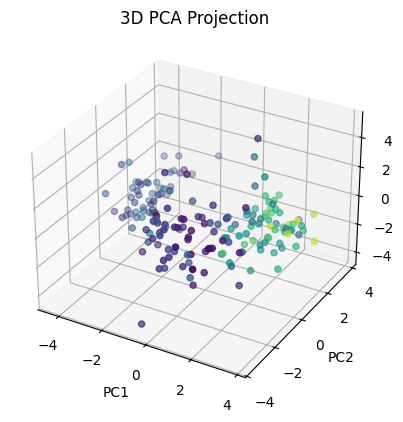

In [8]:
print("Hariharan V S - 24BAD030")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('/content/exp 8 - 2 ml Wine dataset.csv')

print("Missing values:\n", df.isnull().sum())

df = df.dropna()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:\n", explained_variance)

cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Variance:\n", cumulative_variance)

plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

pca_2 = PCA(n_components=2)
X_reduced_2D = pca_2.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_reduced_2D[:, 0], X_reduced_2D[:, 1], c=y)
plt.title("2D PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

pca_3 = PCA(n_components=3)
X_reduced_3D = pca_3.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_reduced_3D[:, 0], X_reduced_3D[:, 1], X_reduced_3D[:, 2], c=y)

ax.set_title("3D PCA Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()